# Geopandas 3: Radykalna Kartografia, Jigsaw Puzzle i Wybory Prezydenckie
---

Witaj na ostatnich zajęciach z serii dotyczącej map i pakietu `geopandas`! Dzisiaj wejdziemy na najwyższy poziom wtajemniczenia. Połączymy wiedzę programistyczną z dwiema potężnymi filozofiami wizualizacji danych:
1. **Storytelling with Data (Cole Nussbaumer Knaflic)** – będziemy świadomie kierować uwagą widza.
2. **Radical Cartography (m.in. Denis Wood)** – "Radykalna Kartografia" to nurt, który obala mit, że mapa jest obiektywnym odbiciem rzeczywistości. Tradycyjne mapy faworyzują wizualnie obszary o dużej powierzchni (np. wielkie, zalesione gminy), ukrywając to, co dzieje się w gęsto zaludnionych, małych miastach. Zastosujemy technikę abstrakcji (przypominającą *jigsaw puzzle* / kafelki), aby nadać każdemu okręgowi wyborczemu taką samą wagę wizualną.

**Cel dzisiejszych zajęć:**
Przeanalizujemy dane o frekwencji z Wyborów Prezydenckich 2025 r. (I tura) w Polsce na poziomie gmin. Zobaczymy, jak frekwencja zmieniała się między godziną 12:00 a 17:00 i jak opowiedzieć o tym rzetelną, wizualną historię.

**Źródła danych (Przygotowanie przed zajęciami):**
1. **Dane PKW (Frekwencja):** Pobierz pliki CSV dla frekwencji do godz. 12:00 oraz 17:00 ze strony: `https://prezydent2025.pkw.gov.pl/prezydent2025/pl/dane_w_arkuszach` i wgraj je do środowiska Google Colab.
2. **Mapa Polski (GUGiK - CAPAP):** Wejdź na stronę `https://capap.gugik.gov.pl/cat/org/gugik/dane/jednostki-administracyjne-f5cnk`. Zjedź w dół do sekcji "Pobierz", kliknij przycisk obok formatu GeoJSON dla **Gmin**. Zapisz ten duży plik na dysku i wgraj do środowiska Colaba.

## Zadanie 1: Przygotowanie Danych Przestrzennych i Wyborczych (Data Prep)
---

Zanim narysujemy jakąkolwiek mapę, musimy połączyć dane statystyczne o frekwencji wyborczej (PKB) z przestrzennymi kształtami gmin od GUGiK. Dane PKW są na poziomie obwodów, więc najpierw je zagregujemy (podsumujemy) do poziomu gminy.

Aby przygotować grunt pod późniejsze zadania "Radykalnej Kartografii", wyznaczymy geometryczne środki gmin (Centroidy). Zrobimy to jednak bezpowrotnie **nie niszcząc** oryginalnych kształtów – zapiszemy je w **dodatkowej kolumnie geometrycznej** o nazwie `'centroid'`. Dzięki temu w jednej tabeli będziemy mieli i punkty, i wielokąty!

---
**Ważne funkcje do zapamiętania:**
* `pd.read_csv('plik.csv', sep=';')` – polskie pliki CSV używają średnika jako separatora.
* `df['TERYT'] = df['TERYT gminy'].astype(str).str.zfill(6)` – zamiana kodów TERYT na 6-znakowy tekst z wiodącymi zerami.
* `gdf_mapa['TERYT_clean'] = gdf_mapa['teryt'].str[:6]` – obcięcie 7-cyfrowego kodu TERYT z GeoJSON do 6 znaków (by pasowało do PKW).
* `gdf_final['centroid'] = gdf_final.geometry.centroid` – wylicza środek ciężkości dla każdego wielokąta i zapisuje w nowej kolumnie.

---
**Instrukcja krok po kroku:**
1. Wczytaj dwa pliki z PKW (godz. 12 i 17) używając `sep=';'`.
2. Znormalizuj kody TERYT do 6 znaków (dodaj wiodące zera).
3. Zgrupuj dane po `TERYT` sumując liczbę wyborców oraz liczbę wydanych kart, a następnie wylicz poprawną frekwencję: `(Suma Kart / Suma Wyborców) * 100`.
4. Wykonaj `pd.merge()` łącząc tabele z godz. 12 i 17 na kluczu `'TERYT'` i wylicz różnicę: `skok_frekwencji = frekwencja_17 - frekwencja_12`.
5. Wczytaj mapę z pliku GeoJSON: `gdf_mapa = gpd.read_file('gminy_gugik.geojson')`.
6. Dostosuj TERYT w mapie: `gdf_mapa['TERYT_clean'] = gdf_mapa['teryt'].str[:6]`.
7. Złącz przestrzenną mapę `gdf_mapa` z wyborczą `df_wybory` po kluczach: `left_on='TERYT_clean'`, `right_on='TERYT'`. Wynik zapisz do `gdf_final`.
8. Oblicz centroidy i zapisz je do nowej kolumny: `gdf_final['centroid'] = gdf_final.geometry.centroid`. Wyświetl próbkę danych.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
frekwencja_12 = pd.read_csv('frekwencja_do_godziny_12_w_drugiej_turze_utf8.csv', sep=';')
frekwencja_17 = pd.read_csv('frekwencja_do_godziny_17_w_drugiej_turze_utf8.csv', sep=';')

for df in [frekwencja_12, frekwencja_17]:
    df['TERYT'] = df['TERYT gminy'].astype(str).str.zfill(6)

agg12 = frekwencja_12.groupby('TERYT').agg(
    wyborcy=('Liczba kart wydanych do godziny 12','sum'),
    karty=('Liczba wyborców do godziny 12','sum')
).reset_index()
agg12['frekwencja_12'] = agg12['karty']/agg12['wyborcy']*100

agg17 = frekwencja_17.groupby('TERYT').agg(
    wyborcy=('Liczba kart wydanych do godziny 17','sum'),
    karty=('Liczba wyborców do godziny 17','sum')
).reset_index()
agg17['frekwencja_17'] = agg17['karty']/agg17['wyborcy']*100

df_wybory = pd.merge(agg12, agg17, on='TERYT', suffixes=('_12', '_17'))
df_wybory['skok_frekwencji'] = df_wybory['frekwencja_17'] - df_wybory['frekwencja_12']

gdf_mapa = gpd.read_file('/content/typ-podpowiedz-nazwa-teryt-parentid-geojson (1).geojson')

gdf_mapa['TERYT_clean'] = gdf_mapa['teryt'].str[:6]

gdf_final = pd.merge(gdf_mapa, df_wybory, left_on='TERYT_clean', right_on='TERYT', how='left')

gdf_final['centroid'] = gdf_final.geometry.centroid
display(gdf_final.head())

/tmp/ipykernel_4664/4282666440.py:34: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_final['centroid'] = gdf_final.geometry.centroid


,teryt,nazwa,podpowiedz,typ,parent_id,geometry,TERYT_clean,TERYT,wyborcy_12,karty_12,frekwencja_12,wyborcy_17,karty_17,frekwencja_17,skok_frekwencji,centroid
0,0222033,Wołów,"gm. Wołów, pow. wołowski, woj. dolnośląskie",gmi,0222,"MULTIPOLYGON (((16.79013 51.42519, 16.79719 51...",022203,022203,3046.0,16236.0,533.026921,8265.0,16327.0,197.543860,-335.483061,POINT (16.60102 51.33576)
1,0214062,Oleśnica,"gm. Oleśnica, pow. oleśnicki, woj. dolnośląskie",gmi,0214,"MULTIPOLYGON (((17.54322 51.3153, 17.53731 51....",021406,021406,2417.0,11630.0,481.175010,6055.0,11714.0,193.459950,-287.715060,POINT (17.43632 51.21282)
2,0223022,Długołęka,"gm. Długołęka, pow. wrocławski, woj. dolnośląskie",gmi,0223,"MULTIPOLYGON (((17.24184 51.268, 17.23884 51.2...",022302,022302,7506.0,29735.0,396.149747,17919.0,29924.0,166.995926,-229.153821,POINT (17.21008 51.18551)
3,0214073,Syców,"gm. Syców, pow. oleśnicki, woj. dolnośląskie",gmi,0214,"MULTIPOLYGON (((17.73495 51.34895, 17.74218 51...",021407,021407,2759.0,12569.0,455.563610,6474.0,12602.0,194.655545,-260.908065,POINT (17.64911 51.30223)
4,0223012,Czernica,"gm. Czernica, pow. wrocławski, woj. dolnośląskie",gmi,0223,"MULTIPOLYGON (((17.37538 51.10414, 17.37139 51...",022301,022301,4108.0,16653.0,405.379747,10277.0,16797.0,163.442639,-241.937108,POINT (17.25181 51.07789)


---
## Zadanie 2: Radykalna Kartografia – Interaktywne Mapy "Jigsaw" dla godz. 12:00 i 17:00
---

W tym zadaniu uciekniemy się do koncepcji **radykalnej przejrzystości cyfrowej**. Zamiast statycznych, drukowanych obrazków, stworzymy nowoczesne mapy webowe, po których użytkownik może dowolnie nawigować, przybliżać je i najeżdżać myszką na punkty, aby sprawdzać konkretne wyniki.

Wygenerujemy **dwie interaktywne mapy punktowe (Dot Maps)** – pierwszą dla frekwencji porannej (do 12:00) oraz drugą dla popołudniowej (do 17:00) i wyświetlimy je **jedna pod drugą**. Pozwoli to nam zaobserwować przestrzenny proces mobilizacji Polaków w ciągu dnia.

---
**Ważne pojęcia i funkcje do zapamiętania:**
* `gdf.set_geometry('centroid')` – tymczasowo ustawia naszą wyliczoną w Zadaniu 1 kolumnę z kropkami jako aktywną geometrię do rysowania. Dzięki temu zachowujemy równe wagi wizualne dla każdej gminy (każda gmina to kropka tej samej wielkości).
* `gdf.explore(...)` – generuje interaktywną mapę webową na kafelkach mapowych.
* **Argumenty metody `.explore()`:**
  * `column='nazwa_kolumny'` – wskazuje kolumnę z danymi liczbowymi do pokolorowania punktów.
  * `cmap='plasma'` – paleta kolorów (jaskrawa i bardzo kontrastowa na ciemnym tle map internetowych).
  * `tooltip=['kol1', 'kol2']` – lista kolumn z tabeli, które mają się natychmiast wyświetlić w dymku po najechaniu kursorem na dany punkt.
  * `marker_kwds={'radius': 6}` – ustawia promień (wielkość) kropek na mapie.
  * `height='450px'` – określa wysokość okna mapy w przeglądarce, co zapobiegnie "rozjeżdżaniu się" notatnika pionowo. Możecie dostosować tak żeby było ładnie :)
* `display(mapa)` – funkcja systemowa środowiska Jupyter, która wymusza wyrenderowanie i wyświetlenie obiektu (w tym przypadku mapy HTML) na ekranie. Użycie jej dwukrotnie pozwoli wyświetlić obie mapy jedna pod drugą.

---
**Instrukcja krok po kroku:**
1. Zaimportuj funkcję wyświetlania: `from IPython.display import display`.
2. Aktywuj kolumnę z kropkami jako naszą główną geometrię rysowania: `gdf_punkty = gdf_final.set_geometry('centroid')`.
3. Dla płynnego i szybkiego działania przeglądarki w Google Colab, pobierz losową próbkę 300 gmin: `gdf_punkty_sample = gdf_punkty.sample(300, random_state=42)`.
4. Wygeneruj pierwszą mapę dla godziny 12:00: `mapa_12 = gdf_punkty_sample.explore(...)`. Podaj parametry: `column='frekwencja_12'`, `cmap='plasma'`, `tooltip=['nazwa', 'frekwencja_12']`, `marker_kwds={'radius': 6}`, `height='450px'`.
5. Wygeneruj drugą mapę dla godziny 17:00 (zapisz jako `mapa_17`) zmieniając kolumnę na `'frekwencja_17'` oraz tooltip na `['nazwa', 'frekwencja_17']`.
6. Wyświetl obie mapy sekwencyjnie za pomocą komend `display(mapa_12)` oraz `display(mapa_17)`.

In [2]:
from IPython.display import display

gdf_punkty = gdf_final.set_geometry('centroid')
gdf_punkty_sample = gdf_punkty.sample(300, random_state=42)

mapa_12 = gdf_punkty_sample.explore(
    column='frekwencja_12',
    cmap='plasma',
    tooltip=['nazwa', 'frekwencja_12'],
    marker_kwds={'radius': 6},
    height='450px'
)


print("MAPA A: FREKWENCJA WYBORCZA DO GODZINY 12:00 (Równe wagi gmin)")
display(mapa_12)

MAPA A: FREKWENCJA WYBORCZA DO GODZINY 12:00 (Równe wagi gmin)


In [3]:
mapa_17 = gdf_punkty_sample.explore(
    column='frekwencja_17',
    cmap='plasma',
    tooltip=['nazwa', 'frekwencja_17'],
    marker_kwds={'radius': 6},
    height='450px'
)

print("MAPA B: FREKWENCJA WYBORCZA DO GODZINY 17:00 (Równe wagi gmin)")
display(mapa_17)

MAPA B: FREKWENCJA WYBORCZA DO GODZINY 17:00 (Równe wagi gmin)


---
## Zadanie 3: Make-over Kartogramu Poligonów (Default vs Highlighting)
---

W tym zadaniu wrócimy do naturalnych granic gmin (poligonów). Przeprowadzimy zaawansowany, profesjonalny **Make-over estetyczno-storytellingowy**:
* **Wykres po lewej (Przed):** Wygenerujemy domyślny wykres przestrzenny z Matplotlib (brak rzutu kartograficznego - Polska jest nienaturalnie spłaszczona, czarne grube linie granic wprowadzające szum wizualny). Usuniemy z niego obramowanie oraz wiszące w powietrzu znaczniki osi (tiksy) i ich numery.
* **Wykres po prawej (Po):** Zastosujemy transformację do oficjalnego układu współrzędnych dla Polski (**PUWG 1992 / EPSG:2180**), usuniemy w całości osie (Decluttering) i wdrożymy technikę **"Push to the background"** ze *Storytelling with Data*. Pomalujemy całą mapę na jasnoszaro, a barwami wyróżnimy tylko 10% gmin o najwyższym popołudniowym zrywie wyborczym (skoku frekwencji).

---
**Ważne funkcje i parametry do zapamiętania (Klucz do symetrii i prawdy naukowej):**
* `vmin` i `vmax` – **niezwykle ważne parametry statystyczne!** Aby móc porównywać kolory na dwóch różnych mapach obok siebie, obie mapy muszą dzielić dokładnie tę samą skalę barw. Wyznaczymy globalne minimum i maksimum skoku frekwencji i zablokujemy je na obu mapach. Gdybyśmy tego nie zrobili, prawa mapa przeskalowałaby kolory tylko do przedziału top 10% (co jest manipulacją i błędem wizualizacyjnym!).
* `ax.set_box_aspect(1)` – ta metoda nakazuje Matplotlibowi zamknąć rysowane mapy w kwadratowych kontenerach (pudełkach) o identycznych wymiarach na ekranie. Zapobiega to sytuacji, w której jeden wykres jest szerszy od drugiego.
* `legend_kwds={'orientation': 'horizontal', ...}` – przenosi pasek legendy (colorbar) na dół wykresu. Dzięki temu pionowy pasek z boku nie "ściska" i nie zwęża lewego podwykresy względem prawego.
* `y=1.05` w funkcji `set_title(...)` – wymusza pozycjonowanie obu tytułów dokładnie na tej samej wysokości pionowej nad mapami, gwarantując idealną symetrię linii tekstu.
* `ax1.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)` – wyłącza rysowanie znaczników osi (tiksów) oraz powiązanych z nimi etykiet liczbowych dla osi Y (`left`) oraz osi X (`bottom`).

---
**Instrukcja krok po kroku:**
1. Przywróć oryginalną geometrię wielokątów (granic gmin): `gdf_powierzchnia = gdf_final.set_geometry('geometry')`.
2. Oblicz globalne minimum i maksimum dla kolumny `'skok_frekwencji'`: `min_val = gdf_powierzchnia['skok_frekwencji'].min()`, `max_val = ...` . Przekażemy je później jako `vmin` i `vmax` do obu map.
3. Przygotuj siatkę `1` wiersz i `2` kolumny: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))`.
4. Wymuś identyczny, kwadratowy kształt dla obu podwykresów: wywołaj `ax1.set_box_aspect(1)` oraz `ax2.set_box_aspect(1)`.
5. **WYKRES LEWY (Przed):**
   * Wywołaj na `gdf_powierzchnia` metodę `.plot()`. Przekaż: `ax=ax1`, `column='skok_frekwencji'`, `cmap='viridis'`, `vmin=min_val`, `vmax=max_val`, `legend=True` oraz w słowniku `legend_kwds` parametry: `{'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05}`.
   * Usuń wszystkie cztery krawędzie ramki wykresu, ustawiając ich widoczność na fałsz: `ax1.spines['nazwa_krawedzi'].set_visible(False)`.
   * Usuń wiszące w powietrzu tiksy i liczby za pomocą `ax1.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)`.
   * Nadaj **pogrubiony** tytuł lewej mapie i wyrównaj go na wysokość `y=1.05`.
6. **WYKRES PRAWY (Po):**
   * Projektujemy mapę: `gdf_projektowany = gdf_powierzchnia.to_crs(epsg=2180)`.
   * Oblicz 90. percentyl dla `'skok_frekwencji'` jako zmienną `prog`.
   * Wyfiltruj liderów: `gdf_top = gdf_projektowany[gdf_projektowany['skok_frekwencji'] >= prog]`.
   * Narysuj tło (szara Polska) na `ax2`: `color='whitesmoke'`, `edgecolor='lightgray'`, `linewidth=0.5`.
   * Nałóż liderów (kolorowe gminy) na `ax2` na tym samym płótnie: wywołaj `.plot()` na `gdf_top` przekazując: `ax=ax2`, `column='skok_frekwencji'`, `cmap='viridis'`, `vmin=min_val`, `vmax=max_val` (blokujemy tę samą skalę!), `edgecolor='darkgray'`, `linewidth=0.3`, `legend=True` oraz ten sam poziomy ukierunkowany słownik `legend_kwds`.
   * Wymaż osie w całości za pomocą `ax2.set_axis_off()`.
   * Nadaj prawy tytuł i wyrównaj go na tę samą wysokość `y=1.05`.
7. Wyrenderuj wykres za pomocą `plt.show()`.
---

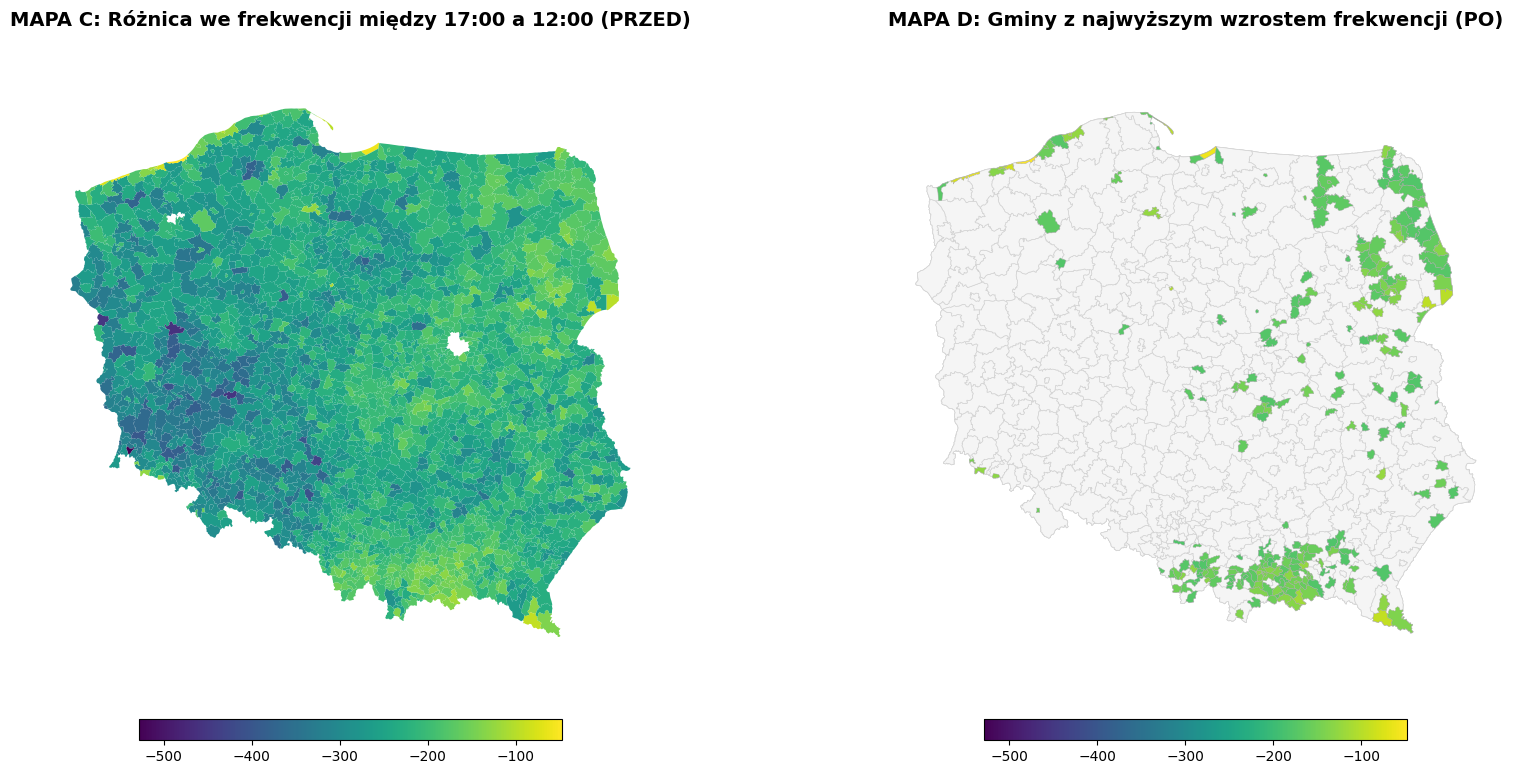

In [4]:
gdf_powierzchnia = gdf_final.set_geometry('geometry')

min_val = gdf_powierzchnia['skok_frekwencji'].min()
max_val = gdf_powierzchnia['skok_frekwencji'].max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

# WYKRES LEWY (Przed):
gdf_powierzchnia.plot(
    ax=ax1,
    column='skok_frekwencji',
    cmap='viridis',
    vmin=min_val,
    vmax=max_val,
    legend=True,
    legend_kwds={'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05}
)

for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
ax1.set_title('MAPA C: Różnica we frekwencji między 17:00 a 12:00 (PRZED)', fontsize=14, fontweight='bold', y=1.05)

# WYKRES PRAWY (Po):
gdf_projektowany = gdf_powierzchnia.to_crs(epsg=2180)

prog = gdf_projektowany['skok_frekwencji'].quantile(0.90)
gdf_top = gdf_projektowany[gdf_projektowany['skok_frekwencji'] >= prog]

gdf_projektowany.plot(
    ax=ax2,
    color='whitesmoke',
    edgecolor='lightgray',
    linewidth=0.5
)

gdf_top.plot(
    ax=ax2,
    column='skok_frekwencji',
    cmap='viridis',
    vmin=min_val,
    vmax=max_val,
    edgecolor='darkgray',
    linewidth=0.3,
    legend=True,
    legend_kwds={'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05}
)

ax2.set_axis_off()
ax2.set_title('MAPA D: Gminy z najwyższym wzrostem frekwencji (PO)', fontsize=14, fontweight='bold', y=1.05)

plt.show()

---
## Zadanie A: Analiza Bliskości (Buffering & Spatial Join)
---

Czas na prawdziwą, zaawansowaną analizę przestrzenną (GIS). Sprawdzimy naukową hipotezę: **"Czy bliskość wielkich metropolii wpływa na frekwencję wyborczą?"**.

Stworzymy fizyczne strefy buforowe o promieniu **30 km** wokół 5 największych miast w Polsce. Następnie sprawdzimy, które gminy leżą wewnątrz tych stref (metropolitalne), a które na zewnątrz (oddalone/wiejskie) i porównamy ich średnią frekwencję.

---
**Uwaga na układ współrzędnych (CRS):**
Aby nałożyć na siebie kontury gmin, koła stref oraz punkty miast, wszystkie elementy **muszą być w tym samym układzie współrzędnych** (oficjalnym PUWG 1992 / EPSG:2180 wyrażonym w metrach). Inaczej mapy rozjadą się w skali i otrzymamy puste tło!

---
**Instrukcja krok po kroku:**
1. Przekształć słownik `dane_miasta` w `GeoDataFrame` i zrzutuj go na układ PUWG 1992: `gdf_miasta = gdf_miasta.to_crs(epsg=2180)`.
2. Stwórz koła buforów o promieniu 30 km wokół tych miast: `gdf_bufory = gdf_miasta.copy()`, a następnie `gdf_bufory['geometry'] = gdf_bufory.geometry.buffer(30000)`.
3. Wykorzystaj punkty (centroidy gmin) z Zadania 2 (`gdf_punkty`). Upewnij się, że są w tym samym układzie: `gdf_punkty_2180 = gdf_punkty.to_crs(epsg=2180)`.
4. Wykonaj **Złączenie Przestrzenne (Spatial Join)** sprawdzające, które kropki gmin wpadły do okręgów miast:
   `gdf_joined = gpd.sjoin(gdf_punkty_2180, gdf_bufory, how='left', predicate='within')`.
5. Zaklasyfikuj gminy: stwórz kolumnę `'Strefa'`. Jeśli po złączeniu kolumna `'Miasto'` ma pustą wartość (`NaN`), przypisz `'Gminy oddalone (Pozostałe)'`. W przeciwnym wypadku przypisz `'Strefa Metropolitalna (<= 30 km)'`.
6. Przenieś wynik tej klasyfikacji na oryginalne wielokąty (poligony) gmin, abyśmy mogli je ładnie pokolorować obszarowo. Zrzutuj `gdf_powierzchnia` na `EPSG:2180` i połącz ją (`merge`) z naszą klasyfikacją po kluczu `'TERYT'`.
7. Wyświetl w konsoli wyliczoną średnią frekwencję o 17:00 dla obu grup.
8. Narysuj spektakularną mapę:
   * Wyrysuj gminy oddalone na jasnoszary kolor.
   * Wyrysuj gminy metropolitalne na delikatny, pastelowy zielony (`'#d1e7dd'`).
   * Nałóż na to zielone, przerywane okręgi stref buforowych (`linestyle='--'`).
   * Nałóż czarne kropki miast i dodaj pętlą bezpośrednie etykiety tekstowe (np. Warszawa, Kraków) tuż obok nich.

Średnia frekwencja o 17:00 dla obu grup:
Strefa
Gminy oddalone (Pozostałe)          191.513222
Strefa Metropolitalna (<= 30 km)    171.946259
Name: frekwencja_17, dtype: float64


/tmp/ipykernel_4664/1843808723.py:131: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower left')


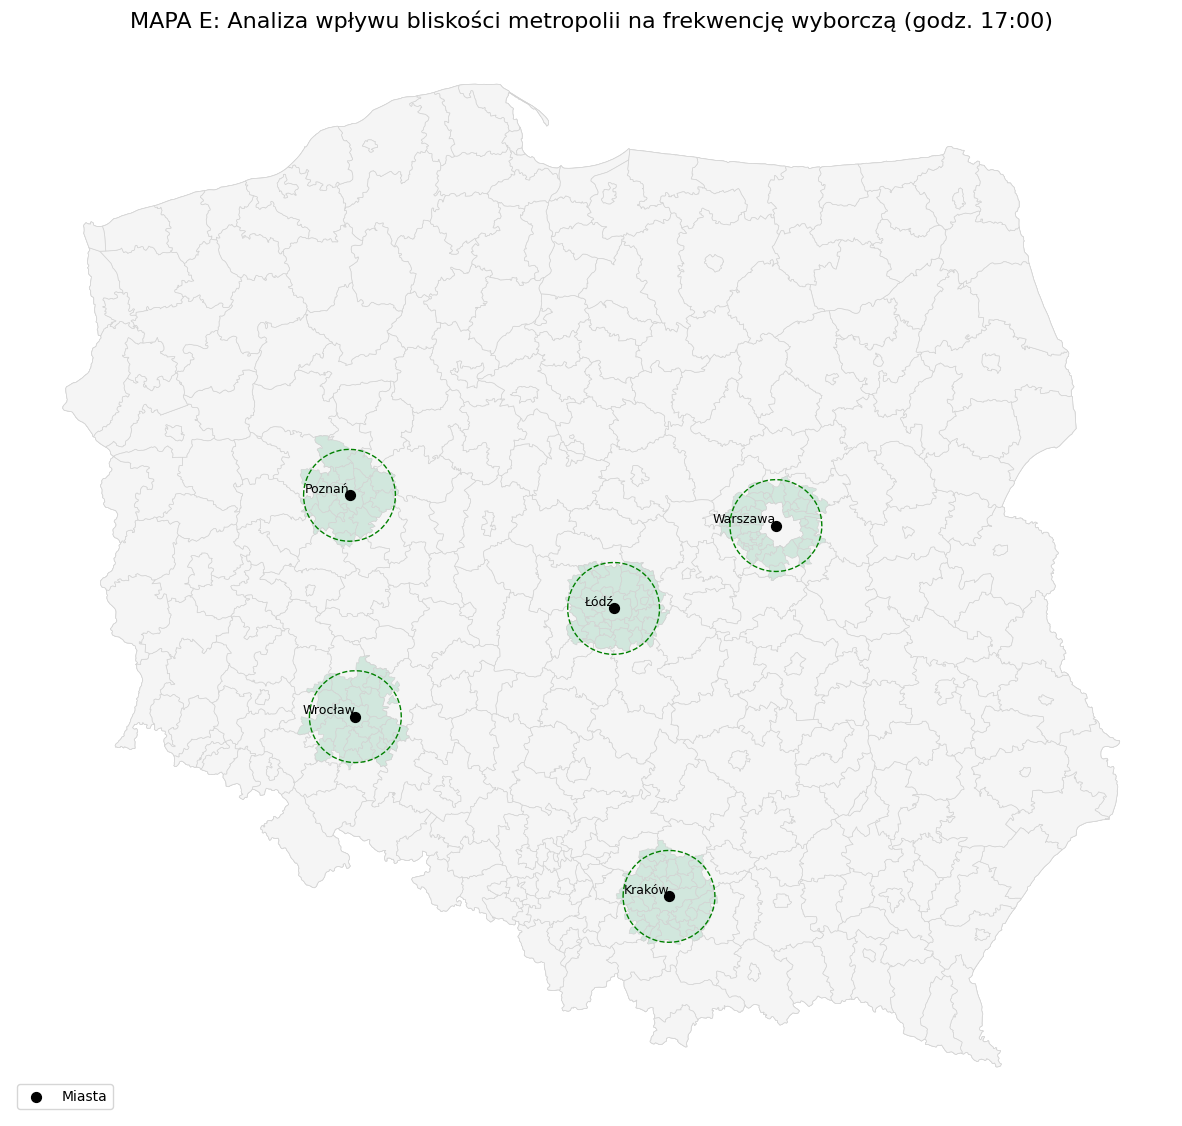

In [39]:
gdf_punkty = gdf_final.set_geometry('centroid')
gdf_powierzchnia = gdf_final.set_geometry('geometry')

dane_miasta = {
    'Miasto':['Warszawa','Kraków','Łódź','Wrocław','Poznań'],
    'lon':[21.0122,19.9445,19.4550,17.0385,16.9252],
    'lat':[52.2297,50.0647,51.7592,51.1079,52.4064]
}

gdf_miasta = gpd.GeoDataFrame(
    dane_miasta,
    geometry=gpd.points_from_xy(
        dane_miasta["lon"],
        dane_miasta["lat"]
    ),
    crs="EPSG:4326"
)

gdf_miasta = gdf_miasta.to_crs(epsg=2180)

gdf_bufory = gdf_miasta.copy()
gdf_bufory['geometry'] = gdf_bufory.geometry.buffer(30000)

gdf_punkty_2180 = gdf_punkty.to_crs(epsg=2180)

gdf_joined = gpd.sjoin(
    gdf_punkty_2180,
    gdf_bufory,
    how='left',
    predicate='within'
)

gdf_joined['Strefa'] = np.where(
    gdf_joined['Miasto'].isna(),
    'Gminy oddalone (Pozostałe)',
    'Strefa Metropolitalna (<= 30 km)'
)

gdf_klasyfikacja = (
    gdf_joined
    .groupby('TERYT')['Miasto']
    .apply(lambda x: x.notna().any())
    .reset_index()
)

gdf_klasyfikacja['Strefa'] = np.where(
    gdf_klasyfikacja['Miasto'],
    'Strefa Metropolitalna (<= 30 km)',
    'Gminy oddalone (Pozostałe)'
)

gdf_klasyfikacja = gdf_klasyfikacja[['TERYT', 'Strefa']]

gdf_powierzchnia_2180 = gdf_powierzchnia.to_crs(epsg=2180)

gdf_powierzchnia_merged = pd.merge(
    gdf_powierzchnia_2180,
    gdf_klasyfikacja,
    on='TERYT',
    how='left'
)

gdf_powierzchnia_merged['Strefa'] = gdf_powierzchnia_merged['Strefa'].fillna(
    'Gminy oddalone (Pozostałe)'
)

mean_frekwencja_by_strefa = (
    gdf_powierzchnia_merged
    .groupby('Strefa')['frekwencja_17']
    .mean()
)

print("Średnia frekwencja o 17:00 dla obu grup:")
print(mean_frekwencja_by_strefa)

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

gdf_powierzchnia_merged[
    gdf_powierzchnia_merged['Strefa'] == 'Gminy oddalone (Pozostałe)'
].plot(
    ax=ax,
    color='whitesmoke',
    edgecolor='lightgray',
    linewidth=0.5,
    label='Gminy oddalone (Pozostałe)'
)

gdf_powierzchnia_merged[
    gdf_powierzchnia_merged['Strefa'] == 'Strefa Metropolitalna (<= 30 km)'
].plot(
    ax=ax,
    color='#d1e7dd',
    edgecolor='lightgray',
    linewidth=0.5,
    label='Strefa Metropolitalna (<= 30 km)'
)

gdf_bufory.plot(
    ax=ax,
    color='none',
    edgecolor='green',
    linestyle='--',
    linewidth=1,
    label='Strefy buforowe (30 km)'
)

gdf_miasta.plot(
    ax=ax,
    marker='o',
    color='black',
    markersize=50,
    label='Miasta'
)

for idx, row in gdf_miasta.iterrows():
    ax.text(
        row.geometry.x,
        row.geometry.y,
        row['Miasto'],
        fontsize=9,
        ha='right',
        va='bottom'
    )

ax.set_title(
    'MAPA E: Analiza wpływu bliskości metropolii na frekwencję wyborczą (godz. 17:00)',
    fontsize=16
)

ax.set_axis_off()
plt.legend(loc='lower left')
plt.show()

---
## Zadanie B: Analiza Anomalii Statystycznych (Z-Score & Diverging Map)

Zwykłe pokazywanie suchych liczb rzadko wywołuje emocje. Prawdziwy analityk szuka **anomalii** (odchyleń od normy). Wykorzystamy statystyczny wskaźnik **Z-Score** (standaryzację), aby odnaleźć gminy, w których popołudniowa mobilizacja drastycznie odbiegała od średniej krajowej.

Narysujemy tzw. **kartogram dewiacyjny** (diverging map). Użyjemy palety dwubiegunowej `coolwarm` (od zimnego niebieskiego dla rekordowo niskiej mobilizacji, przez biel, aż po gorącą czerwień dla ekstremalnego zrywu).

---
**Matematyka anomalii:**
$Z = \frac{X - \mu}{\sigma}$
Gdzie $X$ to skok frekwencji w gminie, $\mu$ to średnia krajowa, a $\sigma$ to odchylenie standardowe. Wynik $Z > 1.5$ oznacza anomalnie wysoki zryw, a $Z < -1.5$ anomalnie niski.

---
**Instrukcja krok po kroku:**
1. Oblicz średnią krajową (`mean`) oraz odchylenie standardowe (`std`) dla kolumny `'skok_frekwencji'` w ramce `gdf_powierzchnia`.
2. Dodaj nową kolumnę `'z_score'`: `(gdf_powierzchnia['skok_frekwencji'] - mean) / std`.
3. Stwórz kolumnę klasyfikacyjną `'anomalia'`:
   * Jeśli `z_score > 1.5` -> `'Ekstremalna Mobilizacja'`
   * Jeśli `z_score < -1.5` -> `'Ekstremalna Bierność'`
   * W pozostałych przypadkach -> `'W normie'`
4. Narysuj kartogram anomalii na osiach `ax`. Jako `column` podaj `'z_score'`.
5. Użyj palety rozbieżnej: `cmap='coolwarm'`. Ustaw limity kolorów `vmin=-3` oraz `vmax=3` za pomocą argumentów w `.plot()`, aby biel wypadła idealnie na wartości zero (średnia krajowa)!
6. Dodaj legendę i wyłącz osie.

ANALIZA ANOMALII FREKWENCJI

Liczba gmin w poszczególnych grupach:
anomalia
W normie                   2572
Ekstremalna Bierność        192
Ekstremalna Mobilizacja     110
Name: count, dtype: int64


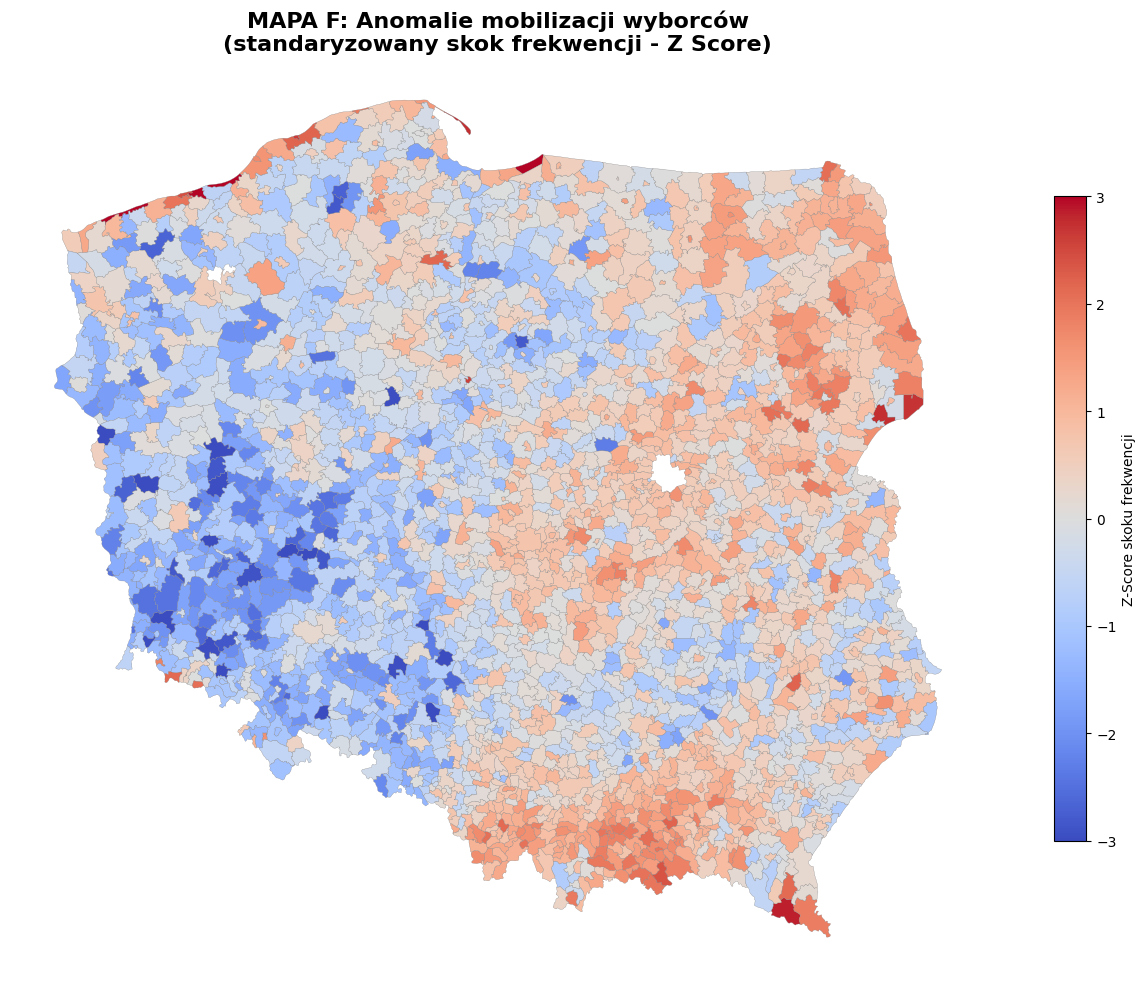

In [6]:
gdf_powierzchnia = gdf_final.set_geometry('geometry')

mean_skok = gdf_powierzchnia['skok_frekwencji'].mean()
std_skok = gdf_powierzchnia['skok_frekwencji'].std()

gdf_powierzchnia['z_score'] = (
    gdf_powierzchnia['skok_frekwencji'] - mean_skok
) / std_skok

gdf_powierzchnia['anomalia'] = np.select(
    [
        gdf_powierzchnia['z_score'] > 1.5,
        gdf_powierzchnia['z_score'] < -1.5
    ],
    [
        'Ekstremalna Mobilizacja',
        'Ekstremalna Bierność'
    ],
    default='W normie'
)

print("ANALIZA ANOMALII FREKWENCJI")

print("\nLiczba gmin w poszczególnych grupach:")
print(gdf_powierzchnia['anomalia'].value_counts())

fig, ax = plt.subplots(figsize=(14, 10))

gdf_powierzchnia.plot(
    column='z_score',
    cmap='coolwarm',
    vmin=-3,
    vmax=3,
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    ax=ax,
    legend_kwds={
        'label': 'Z-Score skoku frekwencji',
        'shrink': 0.7
    }
)

ax.set_title(
    'MAPA F: Anomalie mobilizacji wyborców\n'
    '(standaryzowany skok frekwencji - Z Score)',
    fontsize=16,
    fontweight='bold'
)

ax.set_axis_off()

plt.tight_layout()
plt.show()